# CLI vs MCP: A GitHub Case Study

This notebook explores a broader tooling question for agents: when do you need a dedicated MCP integration, and when can an existing CLI do the job? GitHub is only the case study here. We use it because it is easy to authenticate, inspect, and demo safely.

The notebook progresses through three stages:

1. **MCP path** - the agent gets structured GitHub tools from an MCP server.
2. **Plain CLI path** - the agent gets shell access and must figure out how to use `gh`.
3. **Guided CLI path** - the same shell-based agent receives stronger guidance through prompt hints and a reusable skill.

The point is to examine a real shift in agent tooling: moving work that might have been modeled as MCP back onto existing CLIs. We use this notebook to compare the current MCP approach with a CLI-first migration path and to see what extra guidance the CLI route needs in practice.

In [37]:
import sys
from pathlib import Path

experiments_root = str(Path("..").resolve())
if experiments_root not in sys.path:
    sys.path.append(experiments_root)

from notebook_helpers import arun_agent

## Setup

First we load shared notebook helpers, environment variables, the model name, and the test prompt that we will reuse across all agent configurations. Keeping the user request fixed is important: it lets us compare interface choices rather than accidentally comparing different tasks.

In [38]:
from dotenv import load_dotenv
from pathlib import Path
import os

dotenv_path = Path(".env").resolve()
if load_dotenv(dotenv_path=dotenv_path, override=True):
    print(f"Environment loaded from: {dotenv_path}")
else:
    print(f"No .env file found at: {dotenv_path}; relying on existing environment")

for env_var in ("OPENAI_API_KEY", "LANGCHAIN_TRACING_V2", "LANGCHAIN_API_KEY", "LANGCHAIN_PROJECT", "GITHUB_PERSONAL_ACCESS_TOKEN"):
    status = "SET" if os.getenv(env_var) else "NOT SET"
    print(f"{env_var}: {status}")

token = os.getenv("GITHUB_PERSONAL_ACCESS_TOKEN", "")
if token:
    print(f"GITHUB_PERSONAL_ACCESS_TOKEN suffix: {token[-4:]}")

Environment loaded from: /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-lab/experiments/02-cli-vs-mcp/.env
OPENAI_API_KEY: SET
LANGCHAIN_TRACING_V2: SET
LANGCHAIN_API_KEY: SET
LANGCHAIN_PROJECT: NOT SET
GITHUB_PERSONAL_ACCESS_TOKEN: SET
GITHUB_PERSONAL_ACCESS_TOKEN suffix: ur3k


In [39]:
from textwrap import dedent


model = "gpt-5-mini"

SYSTEM_PROMPT = dedent("""
    You are a coding assistant.
    Help the user implement code changes safely and clearly.
    When needed, use available tools to inspect files, run commands, and verify results.
    Before making changes, briefly state what you will do.
    After changes, summarize what was changed and why.
""") 
                       
TEST_PROMPT = dedent("""
    Use my authenticated GitHub account, check my 3 most recently updated repositories, 
    read each README, and tell me what I'm focusing on lately.
    Your response should be a maximum of one paragraph.
""")

## 1. MCP Path

We start from the original assumption many teams made: if an agent needs to work with GitHub, the answer is to expose GitHub through MCP tools. In that framing, MCP is not an alternative to shell discovery. It is the primary integration path people reached for.

This section establishes that baseline. Later sections test the newer idea that the alternative was often already there: a mature CLI that agents may be able to use directly, especially once we give them better operational guidance.

In [40]:
from mcp_helpers import load_mcp_servers, redact_mcp_servers

mcp_servers = load_mcp_servers("./mcp_config.json")
redact_mcp_servers(mcp_servers)

{'github-mcp-server': {'url': 'https://api.githubcopilot.com/mcp/',
  'headers': {'Authorization': 'Bearer ghp_...ur3k'},
  'transport': 'streamable_http'}}

In [41]:
from langchain_mcp_adapters.client import MultiServerMCPClient
client = MultiServerMCPClient(mcp_servers)
mcp_tools = await client.get_tools()

In [42]:
from mcp_helpers import print_tool_names_grid

print_tool_names_grid(mcp_tools, cols=3, col_width=40)

Total MCP tools: 44
add_comment_to_pending_review           add_issue_comment                       add_reply_to_pull_request_comment       
assign_copilot_to_issue                 create_branch                           create_or_update_file                   
create_pull_request                     create_pull_request_with_copilot        create_repository                       
delete_file                             fork_repository                         get_commit                              
get_copilot_job_status                  get_file_contents                       get_label                               
get_latest_release                      get_me                                  get_release_by_tag                      
get_tag                                 get_team_members                        get_teams                               
issue_read                              issue_write                             list_branches                           
list_commits

Once the MCP tools are loaded, we inspect them and build an agent around them. Then we run the same GitHub analysis request we will reuse later for the CLI-based agents.

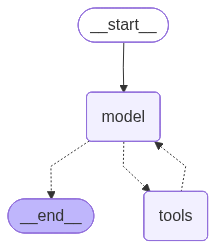

In [29]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from textwrap import dedent
from IPython.display import Image, display

mcp_agent = create_agent(
    model,
    system_prompt=SYSTEM_PROMPT,
    tools=mcp_tools,
)

display(Image(mcp_agent.get_graph(xray=True).draw_mermaid_png()))

In [30]:
messages = await mcp_agent.ainvoke({"messages": [TEST_PROMPT]})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================


Use my authenticated GitHub account, check my 3 most recently updated repositories, 
read each README, and tell me what I'm focusing on lately.
Your response should be a maximum of one paragraph.

================================== Ai Message ==================================

I'll (1) get your GitHub username, (2) list your repositories sorted by most recently updated and take the top 3, and (3) read each repository's README.md. I'll use the GitHub API to fetch these files. I'll start by retrieving your user info.
Tool Calls:
  get_me (call_MoSzgKFIVcLUfzwK1zdOIa0Z)
 Call ID: call_MoSzgKFIVcLUfzwK1zdOIa0Z
  Args:
================================= Tool Message =================================
Name: get_me

[{'type': 'text', 'text': '{"login":"esurovtsev","id":2109127,"profile_url":"https://github.com/esurovtsev","avatar_url":"https://avatars.githubusercontent.com/u/2109127?v=4","details":{"name":"Evgen

## 2. Plain CLI Path

Next we switch to a shell-enabled agent. This is not inventing a new alternative. It is testing the claim that the alternative was already there all along: existing CLIs such as `gh`, with working auth, docs, and commands that humans already use.

This is the first migration step away from MCP. If a mature CLI already exists, can the model use it directly, or does it become too unreliable without extra guidance?

```text
gh
gh auth status
gh repo view esurovtsev/langchain-lab
```

We start with the most naive CLI setup: shell access only. This usually exposes the tradeoff immediately. The model has flexibility, but it also has to choose commands, remember syntax, and decide how to authenticate and inspect results.

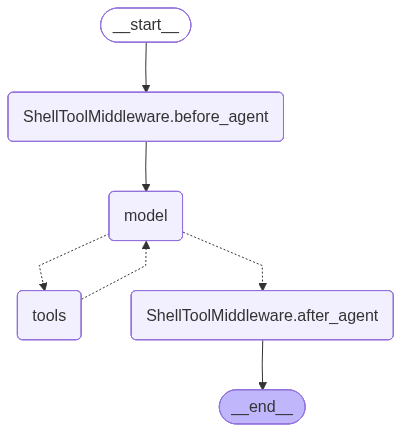

In [31]:
import os
from langchain.agents.middleware import ShellToolMiddleware, HostExecutionPolicy
from textwrap import dedent
from IPython.display import Image, display

shell_agent = create_agent(
    model,
    system_prompt=SYSTEM_PROMPT,
    middleware=[
        ShellToolMiddleware(
            execution_policy=HostExecutionPolicy(),
            env={**os.environ},
        ),
    ],
)

display(Image(shell_agent.get_graph(xray=True).draw_mermaid_png()))

In [34]:
messages = await shell_agent.ainvoke({"messages": [TEST_PROMPT]})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================


Use my authenticated GitHub account, check my 3 most recently updated repositories, 
read each README, and tell me what I'm focusing on lately.
Your response should be a maximum of one paragraph.

================================== Ai Message ==================================

I'll check your GitHub authentication, list your 3 most recently updated repositories, fetch each README, and summarize the recent focus in one short paragraph. I'll run the gh CLI commands to do this. Proceeding to inspect auth and repositories now.
Tool Calls:
  shell (call_SG8kh58mRiHDWqdDTcRKD389)
 Call ID: call_SG8kh58mRiHDWqdDTcRKD389
  Args:
    command: pwd && ls -la && gh --version || true && gh auth status || true
================================= Tool Message =================================
Name: shell

/private/var/folders/b9/3kvdf9zn42v6_9_h1fjs158m0000gn/T/langchain-shell-t1jzo5zf
total 0
drwx------@   2 esurovtsev

### Observation

A shell-capable agent can often reach the answer, but it may hesitate, choose awkward commands, or fall back to ad-hoc exploration. That is exactly the gap this experiment cares about. The next step is not to change the task, but to improve the guidance.

## 3. CLI With Skills

Now we test the more realistic migration path. We keep the CLI-based workflow and add a reusable skill that documents how to use `gh` deterministically for this type of task.

This is the main experiment: if teams move from MCP to CLI, can skills and runbook-style guidance replace enough of the structure that MCP used to package inside a dedicated protocol interface?

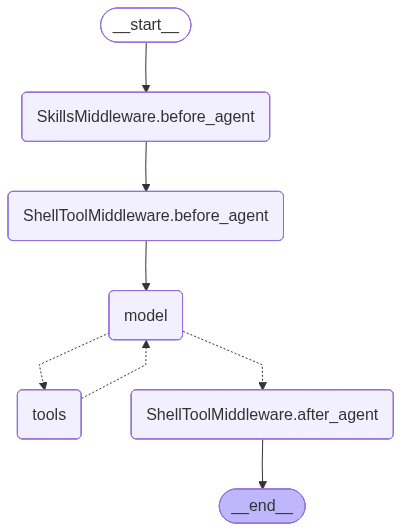

In [35]:
import os
from pathlib import Path
from langchain.agents.middleware import ShellToolMiddleware, HostExecutionPolicy
from deepagents.middleware import SkillsMiddleware
from deepagents.middleware.filesystem import FilesystemMiddleware
from deepagents.backends.filesystem import FilesystemBackend
from textwrap import dedent
from IPython.display import Image, display

skills_backend = FilesystemBackend(
    root_dir=Path(".").resolve(),
    virtual_mode=True,
)

shell_skill_agent = create_agent(
    model,
    system_prompt=SYSTEM_PROMPT,
    middleware=[
        SkillsMiddleware(
            backend=skills_backend,
            sources=["/skills"],
        ),
        FilesystemMiddleware(backend=skills_backend),
        ShellToolMiddleware(
            execution_policy=HostExecutionPolicy(),
            env={**os.environ},
        ),
    ],
)

display(Image(shell_skill_agent.get_graph(xray=True).draw_mermaid_png()))

In this final setup, the agent gets both `SkillsMiddleware` and `FilesystemMiddleware`. That combination matters. The skill metadata alone is only a hint; filesystem access lets the agent actually open `/skills/github-cli/SKILL.md` and follow the documented workflow.

At this point we can distinguish between different failure modes much more clearly:

- wiring problems, where the agent cannot access the skill or files it needs
- model behavior problems, where it ignores or misapplies instructions
- skill design problems, where the instructions themselves are wrong or incomplete

In [36]:
messages = await shell_skill_agent.ainvoke({"messages": [TEST_PROMPT]})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================


Use my authenticated GitHub account, check my 3 most recently updated repositories, 
read each README, and tell me what I'm focusing on lately.
Your response should be a maximum of one paragraph.

================================== Ai Message ==================================

I'll read the github-cli skill instructions, then try to list your most recently updated repositories using the gh CLI and read their READMEs. I'll then summarize what you've been focusing on in one concise paragraph. I'll start by opening the skill documentation.
Tool Calls:
  read_file (call_GjHG0cMzB5zzFLo23QYuRDU7)
 Call ID: call_GjHG0cMzB5zzFLo23QYuRDU7
  Args:
    file_path: /skills/github-cli/SKILL.md
================================= Tool Message =================================
Name: read_file

     1	---
     2	name: github-cli
     3	description: Use this skill for any GitHub-related task. Always read it before using g

## Takeaways

By the end of the notebook, the comparison is no longer just "MCP versus CLI" in the abstract. We have a concrete view of what a migration from MCP to CLI looks like in practice:

- **MCP baseline** shows the integration style many teams initially treated as the default way to expose GitHub to agents.
- **CLI + shell** shows what happens when we try the already-existing CLI as the replacement path, but without much extra help.
- **CLI + skills** shows the more serious migration target: keep the CLI, add reusable operational guidance, and recover reliability without keeping a dedicated protocol layer.

GitHub is only the example. The broader lesson is about a real movement in agent tooling: migrating integrations from MCP-style interfaces toward CLI-first workflows, and understanding what has to be added back in to make that migration work well.